# 🫁 Pneumonia Detection — Chest X-Ray Classification

**Model**: DenseNet-121 (Transfer Learning dari ImageNet)  
**Dataset**: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) — Kaggle  
**Task**: Binary Classification — NORMAL vs PNEUMONIA

---

### 📋 Daftar Isi
1. **Setup & Install Dependencies**
2. **Download Dataset dari Kaggle**
3. **Konfigurasi**
4. **Utilitas**
5. **Preprocessing (CLAHE, Denoise, Resize)**
6. **Dataset & DataLoader**
7. **Model (DenseNet + Custom Head)**
8. **Training (Two-Phase Fine-Tuning)**
9. **Evaluasi (Metrics + Plots)**
10. **Prediksi Single Image**
11. **Download Model**

---


---
## 1. Setup & Install Dependencies

In [16]:
# Cek apakah GPU tersedia
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:    {torch.version.cuda}")
else:
    print("⚠️  GPU tidak terdeteksi! Pastikan runtime menggunakan GPU.")
    print("    Pergi ke: Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU:             Tesla T4
CUDA version:    12.8


In [17]:
# Install dependencies yang belum ada di Colab
!pip install -q opencv-python-headless scikit-learn matplotlib

---
## 2. Download Dataset dari Kaggle

Ada **2 cara** untuk mengunduh dataset:

- **Cara 1 (Recommended)**: Menggunakan Kaggle API dengan `kaggle.json`
- **Cara 2**: Download manual dan upload ke Colab/Google Drive

### Cara 1: Menggunakan Kaggle API

1. Buka https://www.kaggle.com/settings → Scroll ke **API** → Klik **Create New Token**
2. File `kaggle.json` akan terdownload otomatis
3. Jalankan cell di bawah dan upload file `kaggle.json` saat diminta

In [ ]:
import os
from pathlib import Path

# Buat direktori kaggle config
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Upload kaggle.json
from google.colab import files
print("📤 Upload file kaggle.json dari komputer kamu:")
uploaded = files.upload()

# Pindahkan ke lokasi yang benar
import shutil
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("kaggle.json berhasil dikonfigurasi!")

In [18]:
# Download dataset dari Kaggle
!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data --unzip
print("\nDataset berhasil didownload dan diekstrak!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:12<00:00, 18.5MB/s]


✅ Dataset berhasil didownload dan diekstrak!


In [19]:
!rm -r /content/data/chest_xray/__MACOSX/

In [20]:
# Verifikasi struktur dataset
import os

# Dataset Kaggle kadang punya nested folder, kita handle itu
RAW_DATA_ROOT = Path("/content/data/chest_xray")

# Cek apakah ada nested chest_xray/chest_xray
nested = RAW_DATA_ROOT / "chest_xray"
if nested.exists() and (nested / "train").exists():
    RAW_DATA_ROOT = nested
    print(f"📂 Nested folder terdeteksi, menggunakan: {RAW_DATA_ROOT}")

# Tampilkan struktur
for split in ["train", "val", "test"]:
    split_dir = RAW_DATA_ROOT / split
    if split_dir.exists():
        for cls in ["NORMAL", "PNEUMONIA"]:
            cls_dir = split_dir / cls
            if cls_dir.exists():
                count = len(list(cls_dir.glob("*.jpeg"))) + len(list(cls_dir.glob("*.jpg")))
                print(f"  {split:5s}/{cls:10s}: {count:5d} images")
            else:
                print(f"  {split:5s}/{cls:10s}: ❌ NOT FOUND")
    else:
        print(f"  {split}: ❌ NOT FOUND")

print(f"\n📍 RAW_DATA_ROOT = {RAW_DATA_ROOT}")

📂 Nested folder terdeteksi, menggunakan: /content/data/chest_xray/chest_xray
  train/NORMAL    :  1341 images
  train/PNEUMONIA :  3875 images
  val  /NORMAL    :     8 images
  val  /PNEUMONIA :     8 images
  test /NORMAL    :   234 images
  test /PNEUMONIA :   390 images

📍 RAW_DATA_ROOT = /content/data/chest_xray/chest_xray


---
## 3. Konfigurasi

Semua hyperparameter dan path terpusat di sini. Edit sesuai kebutuhan.

In [21]:
import os
from pathlib import Path

# =====================================================================
# KONFIGURASI — Edit nilai-nilai di bawah ini sesuai kebutuhan
# =====================================================================

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
# Dataset raw (dari Kaggle download)
# RAW_DATA_ROOT sudah didefinisikan di cell sebelumnya

# Dataset yang sudah dipreprocess (akan dibuat oleh pipeline)
DATA_ROOT = Path("/content/data/chest_xray_processed")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"
TEST_DIR  = DATA_ROOT / "test"

# Checkpoint directory
CHECKPOINT_DIR = Path("/content/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH  = CHECKPOINT_DIR / "best_model.pth"
FINAL_MODEL_PATH = CHECKPOINT_DIR / "final_model.pth"

# ---------------------------------------------------------------------------
# Classes
# ---------------------------------------------------------------------------
CLASS_NAMES   = ["NORMAL", "PNEUMONIA"]
NUM_CLASSES   = 2
POS_LABEL     = 1          # PNEUMONIA adalah kelas positif

# ---------------------------------------------------------------------------
# Image preprocessing
# ---------------------------------------------------------------------------
IMG_SIZE      = 224        # DenseNet input resolution
IMG_CHANNELS  = 3          # grayscale → RGB

# ImageNet normalization statistics
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
USE_CLAHE         = True
CLAHE_CLIP_LIMIT  = 2.0
CLAHE_TILE_SIZE   = (8, 8)

# Centre crop — buang area tepi (bahu, abdomen)
CENTRE_CROP_FRACTION = 0.9

# Augmentation strengths (training only)
AUG_ROTATION_DEGREES = 10
AUG_BRIGHTNESS       = 0.2
AUG_CONTRAST         = 0.2
AUG_HFLIP_PROB       = 0.5

# ---------------------------------------------------------------------------
# Training hyper-parameters
# ---------------------------------------------------------------------------
BATCH_SIZE      = 32
NUM_EPOCHS      = 20
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 1e-4

# Learning-rate scheduler: reduce on plateau
LR_PATIENCE     = 3
LR_FACTOR       = 0.5
MIN_LR          = 1e-7

# Early stopping
EARLY_STOP_PATIENCE = 7

# ---------------------------------------------------------------------------
# DenseNet variant
# ---------------------------------------------------------------------------
DENSENET_VARIANT = "densenet121"   # "densenet121", "densenet169", "densenet201"
PRETRAINED       = True

# Fine-tuning strategy
FINE_TUNE_STRATEGY = "full"        # "head_only" atau "full"
FREEZE_EPOCHS      = 3             # epoch head-only sebelum unfreeze

# ---------------------------------------------------------------------------
# Hardware — otomatis deteksi GPU
# ---------------------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DataLoader workers (di Colab, 2 biasanya optimal)
NUM_WORKERS = 2

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED         = 42
LOG_INTERVAL = 10

print("✅ Konfigurasi dimuat")
print(f"   Device:    {DEVICE}")
print(f"   Model:     {DENSENET_VARIANT}")
print(f"   Epochs:    {NUM_EPOCHS}")
print(f"   Batch:     {BATCH_SIZE}")
print(f"   LR:        {LEARNING_RATE}")
print(f"   Strategy:  {FINE_TUNE_STRATEGY} (freeze {FREEZE_EPOCHS} epochs)")

✅ Konfigurasi dimuat
   Device:    cuda
   Model:     densenet121
   Epochs:    20
   Batch:     32
   LR:        0.0001
   Strategy:  full (freeze 3 epochs)


---
## 4. Utilitas (Seed, AverageMeter, Timer)

In [22]:
import logging
import random
import sys
import time
from typing import Optional

import numpy as np
import torch


def set_seed(seed: int = 42) -> None:
    """
    Set semua random seed untuk reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


class AverageMeter:
    """Keeps a running average of a scalar metric."""

    def __init__(self, name: str = ""):
        self.name = name
        self.reset()

    def reset(self) -> None:
        self.val   = 0.0
        self.avg   = 0.0
        self.sum   = 0.0
        self.count = 0

    def update(self, val: float, n: int = 1) -> None:
        self.val    = val
        self.sum   += val * n
        self.count += n
        self.avg    = self.sum / self.count if self.count else 0.0

    def __repr__(self) -> str:
        return f"AverageMeter(name={self.name!r}, avg={self.avg:.4f}, count={self.count})"


def format_time(seconds: float) -> str:
    """Convert detik ke format human-readable."""
    seconds = int(seconds)
    h, rem  = divmod(seconds, 3600)
    m, s    = divmod(rem, 60)
    if h:
        return f"{h}h {m:02d}m {s:02d}s"
    if m:
        return f"{m}m {s:02d}s"
    return f"{s}s"


# Set seed sekarang
set_seed(SEED)
print("✅ Utilitas dimuat & seed di-set")

✅ Utilitas dimuat & seed di-set


---
## 5. Preprocessing Pipeline

Pipeline preprocessing untuk chest X-ray:
1. **Load** — buka gambar, konversi ke grayscale
2. **Denoise** — median filter ringan
3. **CLAHE** — tingkatkan kontras lokal
4. **Resize** — aspect-ratio-preserving resize dengan padding
5. **Centre Crop** — buang tepi yang tidak relevan
6. **Grayscale → RGB** — replikasi channel untuk ImageNet weights
7. **ToTensor + Normalize** — normalisasi ImageNet

In [23]:
from __future__ import annotations

from typing import Union

import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
import torch


# ---------------------------------------------------------------------------
# Step 1 – Load & validate
# ---------------------------------------------------------------------------

def load_image(source: Union[str, Path, bytes, Image.Image]) -> Image.Image:
    """
    Load image dari file path, raw bytes, atau PIL Image.
    Selalu mengembalikan PIL Image dalam mode 'L' (grayscale).
    """
    if isinstance(source, Image.Image):
        img = source
    elif isinstance(source, (bytes, bytearray)):
        import io
        img = Image.open(io.BytesIO(source))
    else:
        img = Image.open(str(source))
    return img.convert("L")


# ---------------------------------------------------------------------------
# Step 2 – Denoise (median filter)
# ---------------------------------------------------------------------------

def denoise(img: Image.Image, kernel_size: int = 3) -> Image.Image:
    """
    Median filter ringan untuk mengurangi sensor noise.
    kernel_size=3 cukup konservatif agar tidak blur diagnostically relevant edges.
    """
    if kernel_size < 2:
        return img
    arr      = np.array(img, dtype=np.uint8)
    denoised = cv2.medianBlur(arr, ksize=kernel_size)
    return Image.fromarray(denoised)


# ---------------------------------------------------------------------------
# Step 3 – CLAHE
# ---------------------------------------------------------------------------

def apply_clahe(
    img:        Image.Image,
    clip_limit: float            = CLAHE_CLIP_LIMIT,
    tile_size:  tuple[int, int]  = CLAHE_TILE_SIZE,
) -> Image.Image:
    """
    Enhance local contrast menggunakan CLAHE.
    CLAHE membatasi amplifikasi kontras per tile, menjaga
    tekstur perbedaan antara paru normal dan konsolidasi.
    """
    arr      = np.array(img, dtype=np.uint8)
    clahe    = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    enhanced = clahe.apply(arr)
    return Image.fromarray(enhanced)


# ---------------------------------------------------------------------------
# Step 4 – Aspect-ratio-preserving resize with padding
# ---------------------------------------------------------------------------

def resize_with_padding(
    img:         Image.Image,
    target_size: int = IMG_SIZE,
    fill_value:  int = 0,
) -> Image.Image:
    """
    Resize ke target_size x target_size dengan aspect ratio terjaga.
    Padding hitam pada sisi yang lebih pendek.
    """
    orig_w, orig_h = img.size
    scale  = target_size / max(orig_w, orig_h)
    new_w  = int(orig_w * scale)
    new_h  = int(orig_h * scale)

    resized = img.resize((new_w, new_h), Image.LANCZOS)

    canvas = Image.new("L", (target_size, target_size), fill_value)
    offset_x = (target_size - new_w) // 2
    offset_y = (target_size - new_h) // 2
    canvas.paste(resized, (offset_x, offset_y))
    return canvas


# ---------------------------------------------------------------------------
# Step 5 – Centre crop
# ---------------------------------------------------------------------------

def centre_crop(
    img:      Image.Image,
    fraction: float = CENTRE_CROP_FRACTION,
) -> Image.Image:
    """
    Crop bagian tengah gambar dan resize kembali.
    Menghilangkan area tepi (bahu, abdomen) yang tidak relevan.
    """
    if fraction >= 1.0:
        return img
    w, h     = img.size
    crop_w   = int(w * fraction)
    crop_h   = int(h * fraction)
    left     = (w - crop_w) // 2
    top      = (h - crop_h) // 2
    cropped  = img.crop((left, top, left + crop_w, top + crop_h))
    return cropped.resize((w, h), Image.LANCZOS)


# ---------------------------------------------------------------------------
# Step 6 – Grayscale → 3-channel RGB
# ---------------------------------------------------------------------------

def to_rgb(img: Image.Image) -> Image.Image:
    """Replikasi grayscale ke 3 channel RGB untuk ImageNet-pretrained models."""
    return img.convert("RGB")


# ---------------------------------------------------------------------------
# Composed preprocessing
# ---------------------------------------------------------------------------

def preprocess_pil(
    source:              Union[str, Path, bytes, Image.Image],
    apply_clahe_flag:    bool  = USE_CLAHE,
    apply_denoise_flag:  bool  = True,
) -> Image.Image:
    """
    Pipeline lengkap: load → denoise → CLAHE → resize+pad → centre_crop → to_rgb
    """
    img = load_image(source)
    if apply_denoise_flag:
        img = denoise(img)
    if apply_clahe_flag:
        img = apply_clahe(img)
    img = resize_with_padding(img, target_size=IMG_SIZE)
    img = centre_crop(img, fraction=CENTRE_CROP_FRACTION)
    img = to_rgb(img)
    return img


# ---------------------------------------------------------------------------
# Custom torchvision Transform
# ---------------------------------------------------------------------------

class CXRPreprocess(torch.nn.Module):
    """
    Custom transform yang menjalankan full CXR preprocessing pipeline.
    Bisa dimasukkan ke dalam transforms.Compose.
    """
    def __init__(self, apply_clahe_flag: bool = USE_CLAHE, apply_denoise_flag: bool = True):
        super().__init__()
        self.apply_clahe_flag   = apply_clahe_flag
        self.apply_denoise_flag = apply_denoise_flag

    def forward(self, img: Image.Image) -> Image.Image:
        return preprocess_pil(
            img,
            apply_clahe_flag=self.apply_clahe_flag,
            apply_denoise_flag=self.apply_denoise_flag,
        )

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(clahe={self.apply_clahe_flag}, denoise={self.apply_denoise_flag})"


def build_train_transform() -> transforms.Compose:
    """Pipeline training: CXR preprocessing → augmentasi → ToTensor → Normalize"""
    return transforms.Compose([
        CXRPreprocess(),
        transforms.RandomHorizontalFlip(p=AUG_HFLIP_PROB),
        transforms.RandomRotation(degrees=AUG_ROTATION_DEGREES),
        transforms.ColorJitter(brightness=AUG_BRIGHTNESS, contrast=AUG_CONTRAST),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ])


def build_val_transform() -> transforms.Compose:
    """Pipeline val/test/inference: CXR preprocessing → ToTensor → Normalize (tanpa augmentasi)"""
    return transforms.Compose([
        CXRPreprocess(),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ])


print("✅ Preprocessing pipeline dimuat")

✅ Preprocessing pipeline dimuat


### 5.1 🔄 Offline Preprocessing ke Disk

Preprocess semua gambar sekali dan simpan ke disk.  
Ini **menghemat CPU time** saat training karena gambar sudah siap pakai.

In [24]:
def run_preprocessing_pipeline(
    src_dir:  Path,
    dst_dir:  Path,
    overwrite: bool = False,
) -> None:
    """
    Preprocess semua JPEG images dari src_dir → dst_dir,
    mempertahankan struktur folder split/class.
    """
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    image_paths = list(src_dir.rglob("*.jpeg")) + list(src_dir.rglob("*.jpg"))
    # Filter out __MACOSX atau file hidden
    image_paths = [p for p in image_paths if "__MACOSX" not in str(p) and not p.name.startswith(".")]
    total = len(image_paths)

    if total == 0:
        print(f"⚠️  Tidak ada JPEG images di {src_dir}")
        return

    print(f"📷 Ditemukan {total} images di {src_dir}")
    print(f"📁 Output → {dst_dir}")
    print(f"   CLAHE={USE_CLAHE}  Denoise=True")

    processed = skipped = errors = 0

    for idx, src_path in enumerate(image_paths, 1):
        rel_path = src_path.relative_to(src_dir)
        dst_path = dst_dir / rel_path

        if not overwrite and dst_path.exists():
            skipped += 1
            continue

        dst_path.parent.mkdir(parents=True, exist_ok=True)

        try:
            img = preprocess_pil(src_path)
            img.save(str(dst_path), format="JPEG", quality=95)
            processed += 1
        except Exception as exc:
            print(f"  ❌ ERROR {src_path}: {exc}")
            errors += 1

        if idx % 500 == 0 or idx == total:
            print(f"  [{idx}/{total}] processed={processed}  skipped={skipped}  errors={errors}")

    print(f"\n✅ Preprocessing selesai! processed={processed}  skipped={skipped}  errors={errors}")


# Jalankan preprocessing
print("🔄 Memulai preprocessing offline...")
print("   Ini memakan waktu beberapa menit untuk ~6000 gambar\n")
run_preprocessing_pipeline(RAW_DATA_ROOT, DATA_ROOT, overwrite=False)

🔄 Memulai preprocessing offline...
   Ini memakan waktu beberapa menit untuk ~6000 gambar

📷 Ditemukan 5856 images di /content/data/chest_xray/chest_xray
📁 Output → /content/data/chest_xray_processed
   CLAHE=True  Denoise=True
  [500/5856] processed=500  skipped=0  errors=0
  [1000/5856] processed=1000  skipped=0  errors=0
  [1500/5856] processed=1500  skipped=0  errors=0
  [2000/5856] processed=2000  skipped=0  errors=0
  [2500/5856] processed=2500  skipped=0  errors=0
  [3000/5856] processed=3000  skipped=0  errors=0
  [3500/5856] processed=3500  skipped=0  errors=0
  [4000/5856] processed=4000  skipped=0  errors=0
  [4500/5856] processed=4500  skipped=0  errors=0
  [5000/5856] processed=5000  skipped=0  errors=0
  [5500/5856] processed=5500  skipped=0  errors=0
  [5856/5856] processed=5856  skipped=0  errors=0

✅ Preprocessing selesai! processed=5856  skipped=0  errors=0


📊 Statistik dataset yang sudah dipreprocess:

  train/NORMAL    :  1341 images
  train/PNEUMONIA :  3875 images
  val  /NORMAL    :     8 images
  val  /PNEUMONIA :     8 images
  test /NORMAL    :   234 images
  test /PNEUMONIA :   390 images


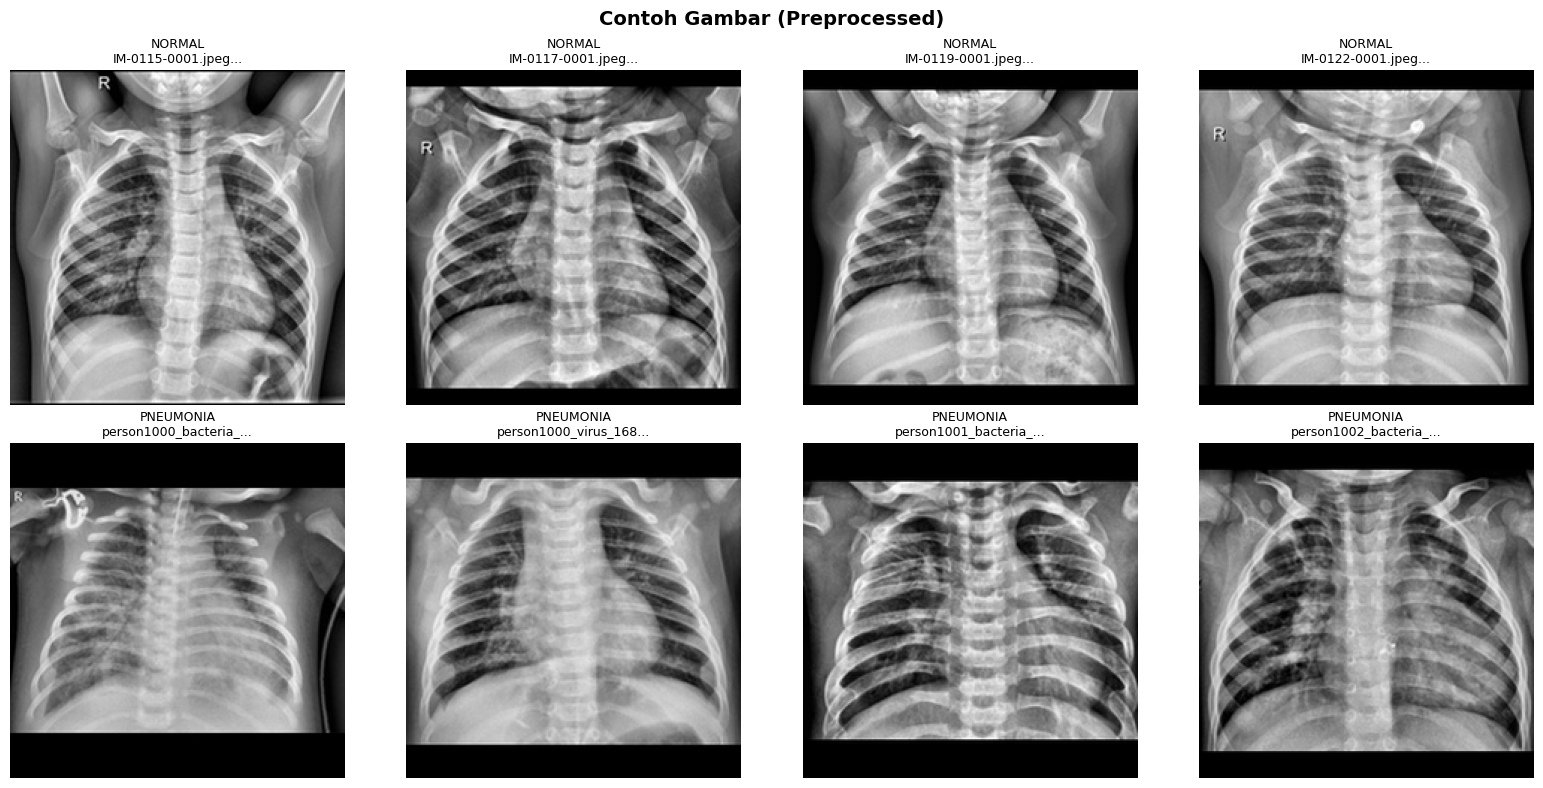

In [25]:
# Verifikasi hasil preprocessing
print("📊 Statistik dataset yang sudah dipreprocess:\n")
for split in ["train", "val", "test"]:
    split_dir = DATA_ROOT / split
    if split_dir.exists():
        for cls in ["NORMAL", "PNEUMONIA"]:
            cls_dir = split_dir / cls
            if cls_dir.exists():
                count = len(list(cls_dir.glob("*.jpeg"))) + len(list(cls_dir.glob("*.jpg")))
                print(f"  {split:5s}/{cls:10s}: {count:5d} images")

# Tampilkan contoh gambar
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Contoh Gambar (Preprocessed)", fontsize=14, fontweight="bold")

for row_idx, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    cls_dir = DATA_ROOT / "train" / cls
    if cls_dir.exists():
        imgs = sorted(cls_dir.glob("*.jpeg"))[:4]
        for col_idx, img_path in enumerate(imgs):
            img = Image.open(img_path)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].set_title(f"{cls}\n{img_path.name[:20]}...", fontsize=9)
            axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

---
## 6. 📂 Dataset & DataLoader

In [26]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets
from typing import Dict


def compute_class_weights(dataset: datasets.ImageFolder) -> torch.Tensor:
    """
    Hitung inverse-frequency class weights untuk menangani class imbalance.
    Returns 1-D tensor [num_classes].
    """
    targets = np.array(dataset.targets)
    class_counts = np.bincount(targets, minlength=NUM_CLASSES).astype(float)
    total = class_counts.sum()
    weights = total / (NUM_CLASSES * class_counts)
    return torch.tensor(weights, dtype=torch.float32)


def make_weighted_sampler(dataset: datasets.ImageFolder) -> WeightedRandomSampler:
    """
    WeightedRandomSampler agar setiap mini-batch kira-kira balanced.
    """
    targets = np.array(dataset.targets)
    class_counts = np.bincount(targets, minlength=NUM_CLASSES).astype(float)
    sample_weights = 1.0 / class_counts[targets]
    sample_weights = torch.tensor(sample_weights, dtype=torch.float64)
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )


def get_datasets() -> Dict[str, datasets.ImageFolder]:
    """Load ImageFolder datasets untuk train / val / test."""
    result = {}
    for split, split_dir, tf in [
        ("train", TRAIN_DIR, build_train_transform()),
        ("val",   VAL_DIR,   build_val_transform()),
        ("test",  TEST_DIR,  build_val_transform()),
    ]:
        if split_dir.exists():
            result[split] = datasets.ImageFolder(root=str(split_dir), transform=tf)
    return result


def get_dataloaders(
    datasets_dict: Dict[str, datasets.ImageFolder],
    use_weighted_sampler: bool = True,
) -> Dict[str, DataLoader]:
    """Wrap datasets dalam DataLoaders."""
    loaders = {}
    for split, ds in datasets_dict.items():
        is_train = split == "train"
        if is_train and use_weighted_sampler:
            sampler = make_weighted_sampler(ds)
            loader = DataLoader(
                ds, batch_size=BATCH_SIZE, sampler=sampler,
                num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
            )
        else:
            loader = DataLoader(
                ds, batch_size=BATCH_SIZE, shuffle=False,
                num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
            )
        loaders[split] = loader
    return loaders


# Load datasets dan dataloaders
print("📂 Loading datasets...")
dsets = get_datasets()
loaders = get_dataloaders(dsets)

for split, ds in dsets.items():
    print(f"  {split:5s}: {len(ds):5d} images  classes={ds.classes}")

# Hitung class weights
if "train" in dsets:
    class_weights = compute_class_weights(dsets["train"])
    print(f"\n⚖️  Class weights: NORMAL={class_weights[0]:.3f}, PNEUMONIA={class_weights[1]:.3f}")

# Cek satu batch
imgs, labels = next(iter(loaders["train"]))
print(f"\n🔍 Sample batch: shape={tuple(imgs.shape)}, labels={labels[:8].tolist()}")

📂 Loading datasets...
  train:  5216 images  classes=['NORMAL', 'PNEUMONIA']
  val  :    16 images  classes=['NORMAL', 'PNEUMONIA']
  test :   624 images  classes=['NORMAL', 'PNEUMONIA']

⚖️  Class weights: NORMAL=1.945, PNEUMONIA=0.673

🔍 Sample batch: shape=(32, 3, 224, 224), labels=[0, 0, 0, 1, 0, 1, 1, 0]


---
## 7. 🧠 Model (DenseNet + Custom Classifier Head)

In [27]:
import torch.nn as nn
from torchvision import models
from typing import Tuple, Optional


class ClassifierHead(nn.Module):
    """
    Replacement head untuk DenseNet classifier.
    Input:  feature vector [batch, in_features] (1024 untuk DenseNet-121)
    Output: logits [batch, 1] untuk BCEWithLogitsLoss
    """
    def __init__(self, in_features: int, dropout: float = 0.4):
        super().__init__()
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(p=dropout / 2),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


def build_model(
    variant:    str   = DENSENET_VARIANT,
    pretrained: bool  = PRETRAINED,
    dropout:    float = 0.4,
) -> nn.Module:
    """
    Build DenseNet model dengan custom binary classifier head.
    """
    weights_enum = {
        "densenet121": models.DenseNet121_Weights.IMAGENET1K_V1,
        "densenet169": models.DenseNet169_Weights.IMAGENET1K_V1,
        "densenet201": models.DenseNet201_Weights.IMAGENET1K_V1,
    }
    if variant not in weights_enum:
        raise ValueError(f"Unknown variant '{variant}'. Choose from {list(weights_enum.keys())}")

    weights  = weights_enum[variant] if pretrained else None
    model_fn = getattr(models, variant)
    backbone = model_fn(weights=weights)

    in_features = backbone.classifier.in_features
    backbone.classifier = ClassifierHead(in_features, dropout=dropout)
    return backbone


def freeze_backbone(model: nn.Module) -> None:
    """Freeze semua parameter kecuali classifier head."""
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False


def unfreeze_backbone(model: nn.Module) -> None:
    """Unfreeze semua parameter untuk full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True


def count_trainable_params(model: nn.Module) -> int:
    """Hitung jumlah parameter yang trainable."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def save_checkpoint(
    model: nn.Module, optimizer: torch.optim.Optimizer,
    epoch: int, val_loss: float, path: Path,
) -> None:
    """Save model checkpoint."""
    torch.save({
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch":                epoch,
        "val_loss":             val_loss,
        "densenet_variant":     DENSENET_VARIANT,
        "num_classes":          NUM_CLASSES,
    }, str(path))


def load_checkpoint(
    path: Path, model: Optional[nn.Module] = None,
    optimizer: Optional[torch.optim.Optimizer] = None,
    device: str = "cpu",
) -> Tuple[nn.Module, dict]:
    """Load checkpoint. Jika model=None, buat model baru dari variant tersimpan."""
    ckpt = torch.load(str(path), map_location=device, weights_only=False)
    if model is None:
        model = build_model(variant=ckpt.get("densenet_variant", DENSENET_VARIANT))
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return model, ckpt


def export_model_for_inference(
    checkpoint_path: Path, output_path: Path, device: str = "cpu",
) -> None:
    """Export model ringan untuk inference (tanpa optimizer state)."""
    ckpt  = torch.load(str(checkpoint_path), map_location=device, weights_only=False)
    model = build_model(variant=ckpt.get("densenet_variant", DENSENET_VARIANT))
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    torch.save({
        "model_state_dict": model.state_dict(),
        "densenet_variant": ckpt.get("densenet_variant", DENSENET_VARIANT),
        "class_names":      CLASS_NAMES,
    }, str(output_path))
    print(f"💾 Inference model saved to: {output_path}")


# Sanity check
model = build_model()
print(f"🧠 Model: {DENSENET_VARIANT}")
print(f"   Total params:          {sum(p.numel() for p in model.parameters()):,}")

freeze_backbone(model)
print(f"   Trainable (head only): {count_trainable_params(model):,}")

unfreeze_backbone(model)
print(f"   Trainable (full):      {count_trainable_params(model):,}")

# Forward pass test
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE)
out   = model(dummy)
print(f"   Output shape: {tuple(out.shape)}  (expected [2, 1])")
del model, dummy, out  # free memory

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 228MB/s]


🧠 Model: densenet121
   Total params:          7,219,073
   Trainable (head only): 265,217
   Trainable (full):      7,219,073
   Output shape: (2, 1)  (expected [2, 1])


---
## 8. 🚀 Training (Two-Phase Fine-Tuning)

- **Phase 1** (epoch 0–2): Hanya classifier head yang di-train → konvergensi cepat
- **Phase 2** (epoch 3+): Seluruh network di-unfreeze dengan LR lebih rendah → akurasi lebih tinggi

In [28]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau


def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    """Jalankan satu epoch training."""
    model.train()
    loss_meter = AverageMeter()
    correct = total = tp = tn = fp = fn = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_meter.update(loss.item(), images.size(0))
        preds = (torch.sigmoid(logits) >= 0.5).long()
        gt    = labels.long()
        correct += (preds == gt).sum().item()
        total   += gt.size(0)
        tp += ((preds == 1) & (gt == 1)).sum().item()
        tn += ((preds == 0) & (gt == 0)).sum().item()
        fp += ((preds == 1) & (gt == 0)).sum().item()
        fn += ((preds == 0) & (gt == 1)).sum().item()

        if (batch_idx + 1) % LOG_INTERVAL == 0:
            print(f"  Epoch {epoch} [{batch_idx+1}/{len(loader)}] "
                  f"loss={loss_meter.avg:.4f}  acc={correct/total:.4f}")

    return {
        "loss": loss_meter.avg,
        "acc":  correct / max(total, 1),
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    """Evaluasi model pada dataloader (val atau test)."""
    model.eval()
    loss_meter = AverageMeter()
    correct = total = tp = tn = fp = fn = 0

    for images, labels in loader:
        images   = images.to(device)
        labels_f = labels.float().unsqueeze(1).to(device)

        logits = model(images)
        loss   = criterion(logits, labels_f)

        loss_meter.update(loss.item(), images.size(0))
        preds = (torch.sigmoid(logits) >= 0.5).long()
        gt    = labels.long().unsqueeze(1).to(device)
        correct += (preds == gt).sum().item()
        total   += gt.size(0)
        tp += ((preds == 1) & (gt == 1)).sum().item()
        tn += ((preds == 0) & (gt == 0)).sum().item()
        fp += ((preds == 1) & (gt == 0)).sum().item()
        fn += ((preds == 0) & (gt == 1)).sum().item()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    precision   = tp / max(tp + fp, 1)
    f1 = 2 * precision * sensitivity / max(precision + sensitivity, 1e-8)

    return {
        "loss": loss_meter.avg, "acc": correct / max(total, 1),
        "sensitivity": sensitivity, "specificity": specificity,
        "precision": precision, "f1": f1,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }


print("✅ Training functions dimuat")

✅ Training functions dimuat


In [29]:
# =====================================================================
# 🚀 MULAI TRAINING
# =====================================================================

set_seed(SEED)
device = DEVICE
print(f"🖥️  Device: {device}")

# ---- Class-weighted loss ----
pos_weight = torch.tensor(
    [class_weights[POS_LABEL].item()], dtype=torch.float32
).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"⚖️  pos_weight={pos_weight.item():.3f}")

# ---- Build Model ----
model = build_model().to(device)
best_val_loss    = float("inf")
no_improve_count = 0

# ---- Phase 1: Freeze backbone ----
if FINE_TUNE_STRATEGY == "full":
    freeze_backbone(model)
    print(f"\n🔒 Phase 1 — Head-only training ({count_trainable_params(model):,} trainable params)")

# ---- Optimizer ----
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_FACTOR,
    patience=LR_PATIENCE, min_lr=MIN_LR,
)

# ---- History untuk plotting ----
history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "val_f1": [], "val_sensitivity": [], "val_specificity": [],
}

# =====================================================================
# Training Loop
# =====================================================================
print("\n" + "=" * 70)
print(" 🏋️ STARTING TRAINING")
print("=" * 70)

total_start = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # --- Unfreeze backbone setelah warm-up ---
    if FINE_TUNE_STRATEGY == "full" and epoch == FREEZE_EPOCHS:
        unfreeze_backbone(model)
        optimizer = Adam(
            model.parameters(),
            lr=LEARNING_RATE * 0.1,
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=LR_FACTOR,
            patience=LR_PATIENCE, min_lr=MIN_LR,
        )
        print(f"\n🔓 Phase 2 — Full fine-tuning ({count_trainable_params(model):,} trainable params)")

    # --- Train ---
    train_metrics = train_one_epoch(
        model, loaders["train"], criterion, optimizer, device, epoch + 1
    )

    # --- Validate ---
    val_metrics = evaluate_one_epoch(
        model, loaders["val"], criterion, device
    )

    scheduler.step(val_metrics["loss"])

    # --- Record history ---
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_sensitivity"].append(val_metrics["sensitivity"])
    history["val_specificity"].append(val_metrics["specificity"])

    elapsed = format_time(time.time() - epoch_start)
    print(
        f"\n📊 Epoch {epoch+1:>3}/{NUM_EPOCHS} ({elapsed}) | "
        f"train loss={train_metrics['loss']:.4f}  acc={train_metrics['acc']:.4f} | "
        f"val loss={val_metrics['loss']:.4f}  acc={val_metrics['acc']:.4f}  "
        f"sens={val_metrics['sensitivity']:.4f}  spec={val_metrics['specificity']:.4f}  "
        f"F1={val_metrics['f1']:.4f}"
    )

    # --- Checkpoint (best model) ---
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        no_improve_count = 0
        save_checkpoint(model, optimizer, epoch, best_val_loss, BEST_MODEL_PATH)
        print(f"  ⭐ New best model saved! (val_loss={best_val_loss:.4f})")
    else:
        no_improve_count += 1
        print(f"  ⏳ No improvement for {no_improve_count} epoch(s).")

    # --- Early stopping ---
    if no_improve_count >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 Early stopping triggered after {epoch+1} epochs.")
        break

# ---- Save final model ----
save_checkpoint(model, optimizer, epoch, val_metrics["loss"], FINAL_MODEL_PATH)
print(f"\n💾 Final model saved to {FINAL_MODEL_PATH}")

# ---- Export inference model ----
inference_path = CHECKPOINT_DIR / "inference_model.pth"
export_model_for_inference(BEST_MODEL_PATH, inference_path)

total_time = format_time(time.time() - total_start)
print(f"\n🎉 Training complete!")
print(f"   Total time:      {total_time}")
print(f"   Best val loss:   {best_val_loss:.4f}")
print(f"   Inference model: {inference_path}")

🖥️  Device: cuda
⚖️  pos_weight=0.673

🔒 Phase 1 — Head-only training (265,217 trainable params)

 🏋️ STARTING TRAINING
  Epoch 1 [10/163] loss=0.5189  acc=0.6469
  Epoch 1 [20/163] loss=0.4310  acc=0.7359
  Epoch 1 [30/163] loss=0.3863  acc=0.7771
  Epoch 1 [40/163] loss=0.3609  acc=0.7945
  Epoch 1 [50/163] loss=0.3333  acc=0.8156
  Epoch 1 [60/163] loss=0.3092  acc=0.8328
  Epoch 1 [70/163] loss=0.2957  acc=0.8397
  Epoch 1 [80/163] loss=0.2840  acc=0.8488
  Epoch 1 [90/163] loss=0.2763  acc=0.8559
  Epoch 1 [100/163] loss=0.2707  acc=0.8591
  Epoch 1 [110/163] loss=0.2658  acc=0.8608
  Epoch 1 [120/163] loss=0.2612  acc=0.8628
  Epoch 1 [130/163] loss=0.2571  acc=0.8635
  Epoch 1 [140/163] loss=0.2475  acc=0.8690
  Epoch 1 [150/163] loss=0.2418  acc=0.8727
  Epoch 1 [160/163] loss=0.2366  acc=0.8758

📊 Epoch   1/20 (30s) | train loss=0.2375  acc=0.8748 | val loss=0.1366  acc=0.9375  sens=1.0000  spec=0.8750  F1=0.9412
  ⭐ New best model saved! (val_loss=0.1366)
  Epoch 2 [10/163] l

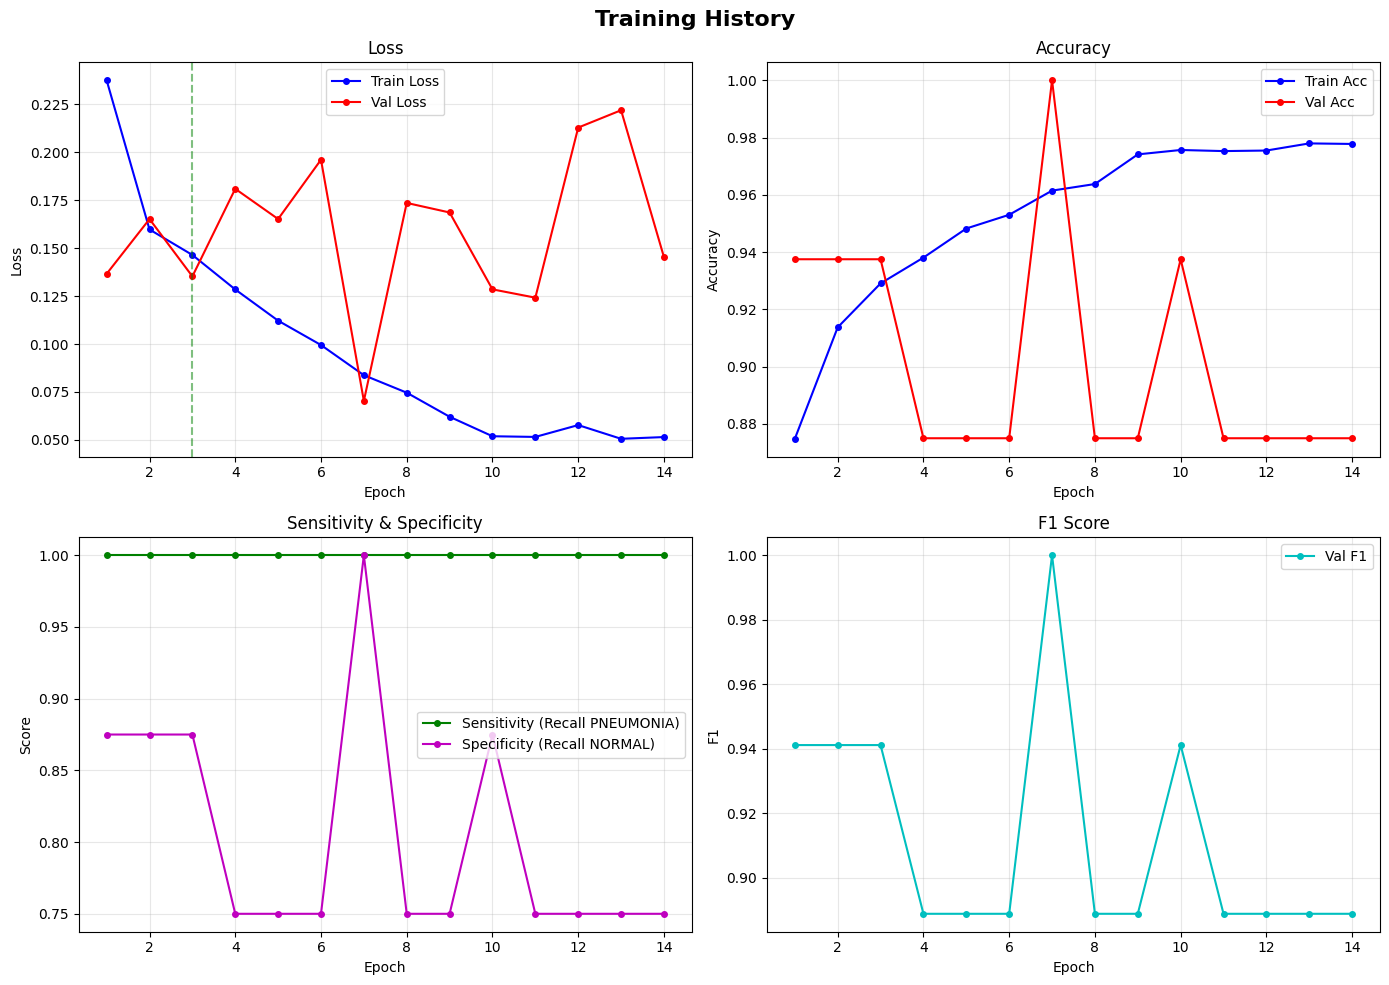

📊 Training history plot saved to /content/checkpoints/training_history.png


In [30]:
# =====================================================================
# 📈 Plot Training History
# =====================================================================
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training History", fontsize=16, fontweight="bold")

# Loss
axes[0, 0].plot(epochs_range, history["train_loss"], "b-o", label="Train Loss", markersize=4)
axes[0, 0].plot(epochs_range, history["val_loss"], "r-o", label="Val Loss", markersize=4)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
if FINE_TUNE_STRATEGY == "full" and FREEZE_EPOCHS < len(history["train_loss"]):
    axes[0, 0].axvline(x=FREEZE_EPOCHS, color="green", linestyle="--", alpha=0.5, label="Unfreeze")

# Accuracy
axes[0, 1].plot(epochs_range, history["train_acc"], "b-o", label="Train Acc", markersize=4)
axes[0, 1].plot(epochs_range, history["val_acc"], "r-o", label="Val Acc", markersize=4)
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Sensitivity & Specificity
axes[1, 0].plot(epochs_range, history["val_sensitivity"], "g-o", label="Sensitivity (Recall PNEUMONIA)", markersize=4)
axes[1, 0].plot(epochs_range, history["val_specificity"], "m-o", label="Specificity (Recall NORMAL)", markersize=4)
axes[1, 0].set_title("Sensitivity & Specificity")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 Score
axes[1, 1].plot(epochs_range, history["val_f1"], "c-o", label="Val F1", markersize=4)
axes[1, 1].set_title("F1 Score")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("F1")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / "training_history.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Training history plot saved to {CHECKPOINT_DIR / 'training_history.png'}")

---
## 9. 📊 Evaluasi pada Test Set

In [31]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import json


@torch.no_grad()
def run_inference(model, loader, device):
    """Full inference pass. Returns (labels, probabilities)."""
    model.eval()
    all_labels = []
    all_probs  = []

    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        probs  = torch.sigmoid(logits).squeeze(1)
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())

    return np.array(all_labels, dtype=int), np.array(all_probs, dtype=float)


def compute_all_metrics(labels, probs, threshold=0.5):
    """Hitung dan print semua classification metrics."""
    preds = (probs >= threshold).astype(int)

    # Classification report
    report = classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)
    print("\n📋 Classification Report:")
    print(report)

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    print("🔲 Confusion Matrix:")
    print(f"             NORMAL  PNEUMONIA")
    print(f"  NORMAL      {tn:5d}    {fp:5d}")
    print(f"  PNEUMONIA   {fn:5d}    {tp:5d}")

    # ROC-AUC
    auc = roc_auc_score(labels, probs)
    print(f"\n🎯 ROC-AUC:     {auc:.4f}")

    # Derived metrics
    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    precision   = tp / max(tp + fp, 1)
    f1 = 2 * precision * sensitivity / max(precision + sensitivity, 1e-8)
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)

    print(f"   Accuracy:    {accuracy:.4f}")
    print(f"   Sensitivity: {sensitivity:.4f}  (recall PNEUMONIA)")
    print(f"   Specificity: {specificity:.4f}  (recall NORMAL)")
    print(f"   Precision:   {precision:.4f}")
    print(f"   F1 score:    {f1:.4f}")

    return {
        "accuracy": float(accuracy), "sensitivity": float(sensitivity),
        "specificity": float(specificity), "precision": float(precision),
        "f1": float(f1), "auc": float(auc),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }


print("✅ Evaluation functions dimuat")

✅ Evaluation functions dimuat


In [32]:
# =====================================================================
# 📊 EVALUASI PADA TEST SET
# =====================================================================

# Load best model
print(f"📦 Loading best model dari {BEST_MODEL_PATH}...")
eval_model, _ = load_checkpoint(BEST_MODEL_PATH, device=DEVICE)
eval_model.eval()

# Run inference
print(f"🔍 Evaluating pada test set ({len(dsets['test'])} images)...\n")
test_labels, test_probs = run_inference(eval_model, loaders["test"], DEVICE)

# Compute metrics
threshold = 0.5
metrics = compute_all_metrics(test_labels, test_probs, threshold=threshold)
metrics["split"]     = "test"
metrics["threshold"] = threshold

# Save results
results_path = CHECKPOINT_DIR / "eval_results.json"
with open(results_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"\n💾 Metrics disimpan ke {results_path}")

📦 Loading best model dari /content/checkpoints/best_model.pth...
🔍 Evaluating pada test set (624 images)...


📋 Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9325    0.6496    0.7657       234
   PNEUMONIA     0.8221    0.9718    0.8907       390

    accuracy                         0.8510       624
   macro avg     0.8773    0.8107    0.8282       624
weighted avg     0.8635    0.8510    0.8439       624

🔲 Confusion Matrix:
             NORMAL  PNEUMONIA
  NORMAL        152       82
  PNEUMONIA      11      379

🎯 ROC-AUC:     0.9563
   Accuracy:    0.8510
   Sensitivity: 0.9718  (recall PNEUMONIA)
   Specificity: 0.6496  (recall NORMAL)
   Precision:   0.8221
   F1 score:    0.8907

💾 Metrics disimpan ke /content/checkpoints/eval_results.json


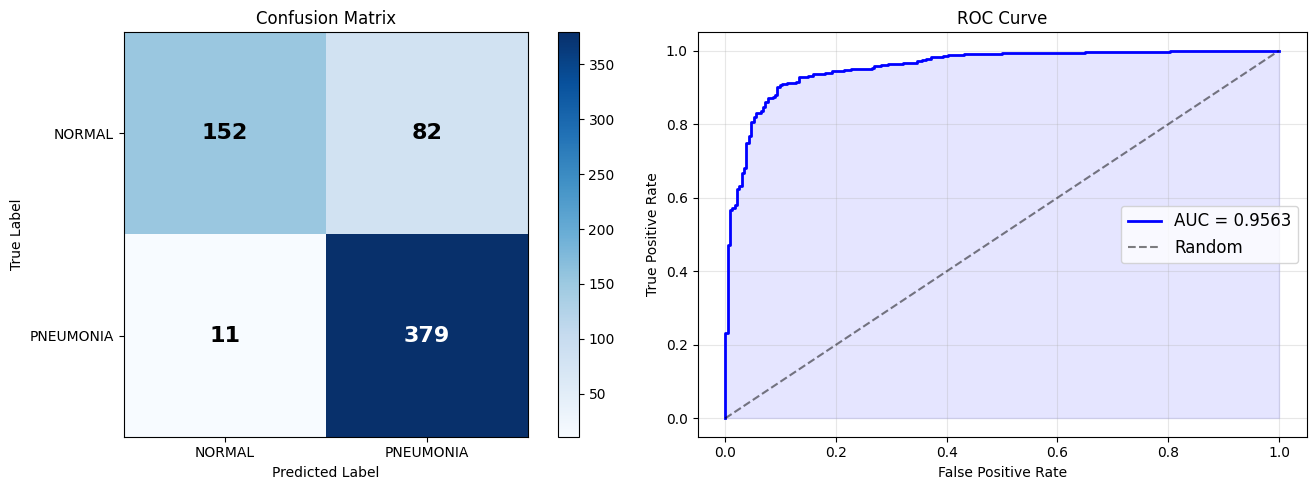

📊 Evaluation plots disimpan ke /content/checkpoints/evaluation_plots.png


In [33]:
# =====================================================================
# 📊 Plot Confusion Matrix & ROC Curve
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
test_preds = (test_probs >= threshold).astype(int)
cm = confusion_matrix(test_labels, test_preds)

im = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=axes[0])
axes[0].set(
    xticks=range(len(CLASS_NAMES)),
    yticks=range(len(CLASS_NAMES)),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ylabel="True Label",
    xlabel="Predicted Label",
    title="Confusion Matrix",
)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black",
                     fontsize=16, fontweight="bold")

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)
auc_score   = roc_auc_score(test_labels, test_probs)

axes[1].plot(fpr, tpr, "b-", linewidth=2, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="blue")
axes[1].set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curve",
)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / "evaluation_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Evaluation plots disimpan ke {CHECKPOINT_DIR / 'evaluation_plots.png'}")

---
## 10. 🔮 Prediksi Single Image

Coba prediksi pada gambar dari test set atau upload gambar sendiri.

In [34]:
class PneumoniaPredictor:
    """
    Stateful predictor: load model sekali, pakai berulang kali.
    """
    def __init__(self, model_path=None, device=DEVICE, threshold=0.5):
        self.device    = device
        self.threshold = threshold
        self.transform = build_val_transform()

        inference_path = CHECKPOINT_DIR / "inference_model.pth"
        if model_path is None:
            model_path = inference_path if inference_path.exists() else BEST_MODEL_PATH

        self.model_path = Path(model_path)
        self.model, _   = load_checkpoint(self.model_path, device=self.device)
        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False
        print(f"✅ Predictor ready | model={self.model_path.name} | device={self.device}")

    @torch.no_grad()
    def predict(self, source):
        """Prediksi satu gambar. Returns dict dengan label, probability, dll."""
        import io as _io
        t0 = time.perf_counter()

        if isinstance(source, Image.Image):
            img = source
        elif isinstance(source, (bytes, bytearray)):
            img = Image.open(_io.BytesIO(source))
        else:
            img = Image.open(str(source))

        tensor = self.transform(img).unsqueeze(0).to(self.device)
        logit  = self.model(tensor)
        prob   = torch.sigmoid(logit).item()

        inference_ms = (time.perf_counter() - t0) * 1000
        label_index  = int(prob >= self.threshold)
        label        = CLASS_NAMES[label_index]
        confidence   = prob if label_index == 1 else 1.0 - prob

        return {
            "label":        label,
            "label_index":  label_index,
            "probability":  round(prob, 6),
            "confidence":   round(confidence, 6),
            "threshold":    self.threshold,
            "inference_ms": round(inference_ms, 2),
        }


# Inisialisasi predictor
predictor = PneumoniaPredictor()

✅ Predictor ready | model=inference_model.pth | device=cuda


/tmp/ipykernel_6506/2139854699.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6506/2139854699.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


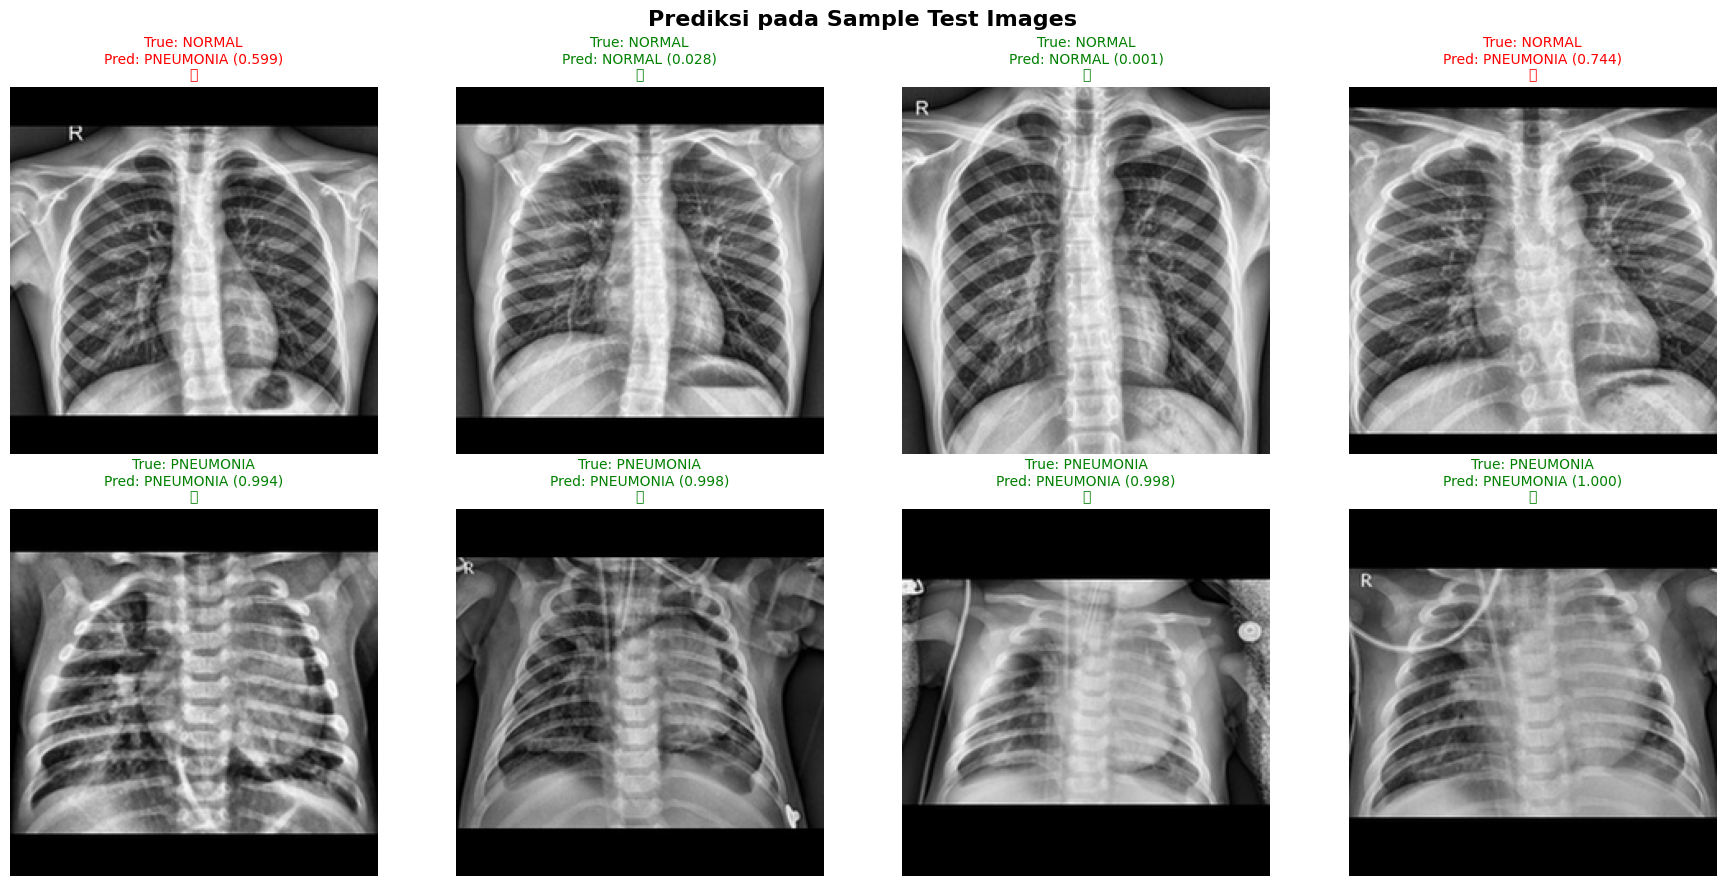

In [35]:
# =====================================================================
# 🔮 Prediksi pada sample gambar dari test set
# =====================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Prediksi pada Sample Test Images", fontsize=16, fontweight="bold")

for row_idx, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    cls_dir = TEST_DIR / cls
    if cls_dir.exists():
        sample_imgs = sorted(cls_dir.glob("*.jpeg"))[:4]
        if not sample_imgs:
            sample_imgs = sorted(cls_dir.glob("*.jpg"))[:4]

        for col_idx, img_path in enumerate(sample_imgs):
            result = predictor.predict(img_path)

            img = Image.open(img_path)
            axes[row_idx, col_idx].imshow(img, cmap="gray")

            pred_label = result["label"]
            prob       = result["probability"]
            correct    = pred_label == cls

            color = "green" if correct else "red"
            symbol = "✅" if correct else "❌"
            axes[row_idx, col_idx].set_title(
                f"True: {cls}\nPred: {pred_label} ({prob:.3f})\n{symbol}",
                fontsize=10, color=color,
            )
            axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

📤 Upload chest X-ray image untuk prediksi:


Saving 2026-06-25 04.23.29.jpg to 2026-06-25 04.23.29.jpg

🔍 Prediksi untuk: 2026-06-25 04.23.29.jpg

   📋 HASIL PREDIKSI
   label          : PNEUMONIA
   label_index    : 1
   probability    : 0.9911
   confidence     : 0.9911
   threshold      : 0.5
   inference_ms   : 45.55


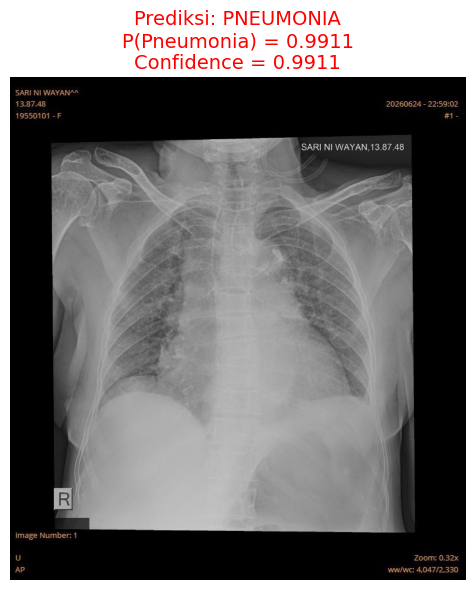

In [36]:
x# =====================================================================
# 📤 Upload & Prediksi Gambar Sendiri
# =====================================================================

from google.colab import files

print("📤 Upload chest X-ray image untuk prediksi:")
uploaded = files.upload()

for filename, content in uploaded.items():
    print(f"\n🔍 Prediksi untuk: {filename}")
    result = predictor.predict(content)

    print(f"\n   {'='*40}")
    print(f"   📋 HASIL PREDIKSI")
    print(f"   {'='*40}")
    for k, v in result.items():
        print(f"   {k:<15}: {v}")

    # Tampilkan gambar
    import io as _io
    img = Image.open(_io.BytesIO(content))
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"Prediksi: {result['label']}\n"
        f"P(Pneumonia) = {result['probability']:.4f}\n"
        f"Confidence = {result['confidence']:.4f}",
        fontsize=14,
        color="red" if result["label"] == "PNEUMONIA" else "green",
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

---
## 11. 💾 Download Model & Results

Download trained model dan hasil evaluasi ke komputer lokal.

In [37]:
from google.colab import files

print("📦 File yang tersedia untuk download:\n")
for f in sorted(CHECKPOINT_DIR.glob("*")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  📄 {f.name:30s} ({size_mb:.1f} MB)")

print("\n" + "="*50)

📦 File yang tersedia untuk download:

  📄 best_model.pth                 (83.5 MB)
  📄 eval_results.json              (0.0 MB)
  📄 evaluation_plots.png           (0.1 MB)
  📄 final_model.pth                (83.5 MB)
  📄 inference_model.pth            (28.1 MB)
  📄 training_history.png           (0.2 MB)



In [ ]:
# Download inference model (paling ringan, untuk deployment)
inference_file = CHECKPOINT_DIR / "inference_model.pth"
if inference_file.exists():
    print(f"📥 Downloading {inference_file.name}...")
    files.download(str(inference_file))
else:
    print("⚠️  inference_model.pth belum ada. Jalankan training dulu.")

In [ ]:
# Download best model (termasuk optimizer state, untuk resume training)
if BEST_MODEL_PATH.exists():
    print(f"📥 Downloading {BEST_MODEL_PATH.name}...")
    files.download(str(BEST_MODEL_PATH))
else:
    print("⚠️  best_model.pth belum ada.")

In [39]:
# Download evaluation results (JSON)
results_file = CHECKPOINT_DIR / "eval_results.json"
if results_file.exists():
    print(f"📥 Downloading {results_file.name}...")
    files.download(str(results_file))
else:
    print("⚠️  eval_results.json belum ada.")

📥 Downloading eval_results.json...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Download semua checkpoints sebagai ZIP
import shutil

zip_path = "/content/pneumonia_checkpoints"
shutil.make_archive(zip_path, "zip", str(CHECKPOINT_DIR))
print(f"📥 Downloading semua checkpoints sebagai ZIP...")
files.download(f"{zip_path}.zip")

📥 Downloading semua checkpoints sebagai ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## ✅ Selesai!

### Ringkasan:
- **Model**: DenseNet-121 dengan custom classifier head
- **Preprocessing**: CLAHE + Denoise + Aspect-ratio resize + Centre crop
- **Training**: Two-phase fine-tuning (head-only → full)
- **Class Imbalance**: WeightedRandomSampler + BCEWithLogitsLoss(pos_weight)
- **Evaluasi**: Accuracy, Sensitivity, Specificity, Precision, F1, ROC-AUC

### File yang dihasilkan:
| File | Keterangan |
|------|------------|
| `best_model.pth` | Model terbaik (untuk resume training) |
| `final_model.pth` | Model terakhir saat training selesai |
| `inference_model.pth` | Model ringan untuk deployment |
| `eval_results.json` | Metrics evaluasi dalam format JSON |
| `training_history.png` | Plot loss/accuracy/F1 per epoch |
| `evaluation_plots.png` | Confusion matrix & ROC curve |